Cloning into 'CIL_data'...
Updating files:  12% (2450/19239)
Updating files:  13% (2502/19239)
Updating files:  14% (2694/19239)
Updating files:  15% (2886/19239)
Updating files:  16% (3079/19239)
Updating files:  17% (3271/19239)
Updating files:  18% (3464/19239)
Updating files:  19% (3656/19239)
Updating files:  20% (3848/19239)
Updating files:  21% (4041/19239)
Updating files:  22% (4233/19239)
Updating files:  23% (4425/19239)
Updating files:  24% (4618/19239)
Updating files:  24% (4701/19239)
Updating files:  25% (4810/19239)
Updating files:  26% (5003/19239)
Updating files:  27% (5195/19239)
Updating files:  28% (5387/19239)
Updating files:  29% (5580/19239)
Updating files:  30% (5772/19239)
Updating files:  31% (5965/19239)
Updating files:  32% (6157/19239)
Updating files:  33% (6349/19239)
Updating files:  34% (6542/19239)
Updating files:  35% (6734/19239)
Updating files:  35% (6900/19239)
Updating files:  36% (6927/19239)
Updating files:  37% (7119/19239)
Updating files:  38% 

CSV_1 existe    : True
CSV_2 existe    : True
IMAGES_1 existe : True
IMAGES_2 existe : True

PART 1: 8401 imagenes
PART 2: 10990 imagenes
Total combinado : 19391 imagenes

Columnas        : ['contributor_id', 'session_id', 'timestamp', 'image_filename', 'steering_angle', 'speed_kmh', 'brake', 'autonomous_mode', 'lane_side', 'line_detected', 'edge_detected', 'gps_x', 'gps_y', 'lidar_obstacle_detected', 'lidar_obstacle_distance', 'behavior_class', 'nav_command', 'obstacle_type']
Distribucion de nav_command:
  0 (LANE_FOLLOW): 13344 imagenes
  1 (STRAIGHT): 1408 imagenes
  2 (LEFT): 1791 imagenes
  3 (RIGHT): 2848 imagenes

Steering angle:
count    19391.000000
mean         0.011296
std          0.158338
min         -0.700000
25%         -0.050000
50%          0.000000
75%         -0.000000
max          0.700000
Name: steering_angle, dtype: float64


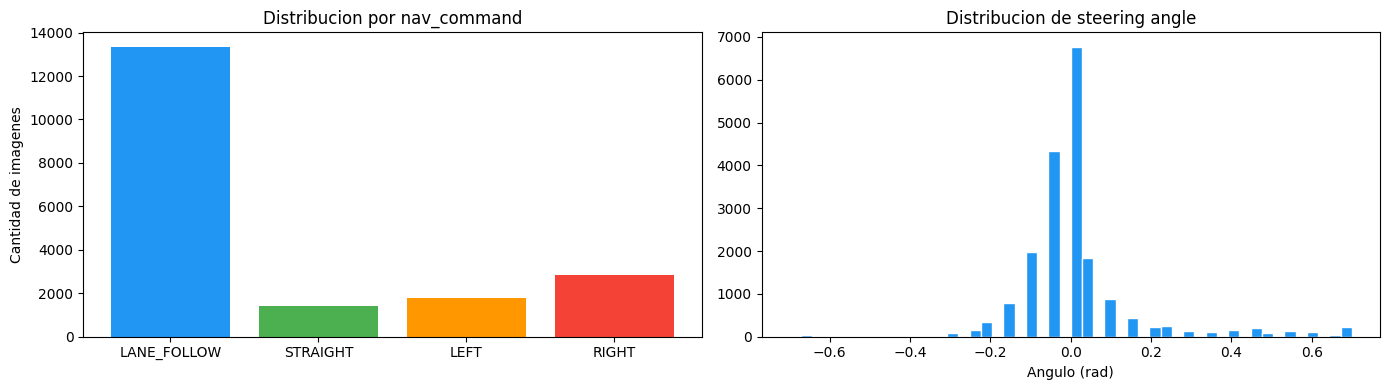

LANE_FOLLOW mantenido completo: 13344

Dataset balanceado: 19391 imagenes
nav_command
0    13344
1     1408
2     1791
3     2848
Name: count, dtype: int64
CILDataset definido correctamente
Train: 15512 muestras  |  243 batches
Val  : 3879 muestras  |  61 batches
Device: cuda
Output shape: torch.Size([4])
Parametros  : 1,477,104


In [ ]:
# ============================================================
# CELDA 1 — Clonar dataset desde GitHub
# ============================================================
!git clone https://github.com/Joseluiscruzvalencia92/CIL_data.git
import os
!ls CIL_data/
!ls CIL_data/PART2/


# ============================================================
# CELDA 2 — Instalar dependencias
# ============================================================
!pip install torch torchvision pandas numpy opencv-python-headless matplotlib scikit-learn -q


# ============================================================
# CELDA 3 — Combinar los dos datasets
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Rutas de ambas partes
CSV_1    = 'CIL_data/measurements.csv'
CSV_2    = 'CIL_data/PART2/measurements.csv'
IMAGES_1 = 'CIL_data/images'
IMAGES_2 = 'CIL_data/PART2/images'

# Verificar que existen
print(f'CSV_1 existe    : {os.path.isfile(CSV_1)}')
print(f'CSV_2 existe    : {os.path.isfile(CSV_2)}')
print(f'IMAGES_1 existe : {os.path.isdir(IMAGES_1)}')
print(f'IMAGES_2 existe : {os.path.isdir(IMAGES_2)}')

# Cargar ambos CSV
df1 = pd.read_csv(CSV_1)
df2 = pd.read_csv(CSV_2)

print(f'\nPART 1: {len(df1)} imagenes')
print(f'PART 2: {len(df2)} imagenes')

# Agregar ruta completa para evitar colision de nombres duplicados
df1['image_filename'] = df1['image_filename'].apply(
    lambda f: os.path.join(IMAGES_1, f))
df2['image_filename'] = df2['image_filename'].apply(
    lambda f: os.path.join(IMAGES_2, f))

# Combinar y mezclar
df = pd.concat([df1, df2]).reset_index(drop=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Total combinado : {len(df)} imagenes')
print(f'\nColumnas        : {list(df.columns)}')


# ============================================================
# CELDA 4 — Distribucion de comandos y steering
# ============================================================
CMD_NAMES = {0: 'LANE_FOLLOW', 1: 'STRAIGHT', 2: 'LEFT', 3: 'RIGHT'}

counts = df['nav_command'].value_counts().sort_index()
print('Distribucion de nav_command:')
for cmd, count in counts.items():
    print(f'  {cmd} ({CMD_NAMES.get(cmd,"?")}): {count} imagenes')

print(f'\nSteering angle:')
print(df['steering_angle'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar([CMD_NAMES.get(c, str(c)) for c in counts.index], counts.values,
            color=['#2196F3','#4CAF50','#FF9800','#F44336'])
axes[0].set_title('Distribucion por nav_command')
axes[0].set_ylabel('Cantidad de imagenes')
axes[1].hist(df['steering_angle'], bins=50, color='#2196F3', edgecolor='white')
axes[1].set_title('Distribucion de steering angle')
axes[1].set_xlabel('Angulo (rad)')
plt.tight_layout()
plt.show()


# ============================================================
# CELDA 5 — Balancear el dataset
# ============================================================
df_intersections = df[df['nav_command'] != 0]
df_lane_follow   = df[df['nav_command'] == 0]

n_intersections = len(df_intersections)
max_lane_follow = max(n_intersections * 3, 2000)

if len(df_lane_follow) > max_lane_follow:
    df_lane_follow = df_lane_follow.sample(max_lane_follow, random_state=42)
    print(f'LANE_FOLLOW reducido a {max_lane_follow}')
else:
    print(f'LANE_FOLLOW mantenido completo: {len(df_lane_follow)}')

df_balanced = pd.concat([df_lane_follow, df_intersections]).reset_index(drop=True)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'\nDataset balanceado: {len(df_balanced)} imagenes')
print(df_balanced['nav_command'].value_counts().sort_index())


# ============================================================
# CELDA 6 — Dataset con Data Augmentation
# ============================================================
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import cv2
import random

IMG_H     = 160
IMG_W     = 320
CROP_TOP  = 0.40
CROP_BOT  = 0.95
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD  = [0.229, 0.224, 0.225]


class CILDataset(Dataset):
    def __init__(self, df, augment=True):
        self.df        = df.reset_index(drop=True)
        self.augment   = augment
        self.normalize = T.Normalize(mean=NORM_MEAN, std=NORM_STD)

    def __len__(self):
        return len(self.df)

    def _load_and_crop(self, filepath):
        # filepath ya tiene la ruta completa
        img = cv2.imread(filepath)
        if img is None:
            return np.zeros((IMG_H, IMG_W, 3), dtype=np.uint8)
        img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        y1   = int(h * CROP_TOP)
        y2   = int(h * CROP_BOT)
        img  = img[y1:y2, :]
        img  = cv2.resize(img, (IMG_W, IMG_H))
        return img

    def __getitem__(self, idx):
        row     = self.df.iloc[idx]
        img     = self._load_and_crop(row['image_filename'])
        angle   = float(row['steering_angle'])
        nav_cmd = int(row['nav_command'])

        if self.augment:
            # Flip horizontal — invierte imagen, angulo y LEFT<->RIGHT
            if random.random() < 0.5:
                img     = cv2.flip(img, 1)
                angle   = -angle
                if nav_cmd == 2:
                    nav_cmd = 3
                elif nav_cmd == 3:
                    nav_cmd = 2
            # Brillo aleatorio
            if random.random() < 0.5:
                factor = random.uniform(0.7, 1.3)
                img    = np.clip(img.astype(np.float32) * factor, 0, 255).astype(np.uint8)
            # Ruido gaussiano
            if random.random() < 0.3:
                noise = np.random.normal(0, 8, img.shape).astype(np.int16)
                img   = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

        t = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        t = self.normalize(t)
        return t, torch.tensor(nav_cmd, dtype=torch.long), torch.tensor(angle, dtype=torch.float32)


print('CILDataset definido correctamente')


# ============================================================
# CELDA 7 — Split train/val y DataLoaders
# ============================================================
from sklearn.model_selection import train_test_split

df_train, df_val = train_test_split(
    df_balanced, test_size=0.2, random_state=42,
    stratify=df_balanced['nav_command'])

train_dataset = CILDataset(df_train, augment=True)
val_dataset   = CILDataset(df_val,   augment=False)

train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True,
                            num_workers=2, pin_memory=True)
val_loader    = DataLoader(val_dataset,   batch_size=64, shuffle=False,
                            num_workers=2, pin_memory=True)

print(f'Train: {len(train_dataset)} muestras  |  {len(train_loader)} batches')
print(f'Val  : {len(val_dataset)} muestras  |  {len(val_loader)} batches')


# ============================================================
# CELDA 8 — Definir modelo CIL (CNN + 4 ramas MLP)
# ============================================================
class CILModel(nn.Module):
    """
    Conditional Imitation Learning model.
    CNN extrae features de la imagen.
    4 ramas MLP — una por nav_command (0=LF, 1=ST, 2=LEFT, 3=RIGHT).
    Solo la rama del comando activo produce el angulo de salida.
    """
    def __init__(self):
        super().__init__()

        # CNN — backbone DAVE-2 (Bojarski et al.)
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 24, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(24), nn.ELU(),
            nn.Conv2d(24, 36, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(36), nn.ELU(),
            nn.Conv2d(36, 48, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(48), nn.ELU(),
            nn.Conv2d(48, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64), nn.ELU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64), nn.ELU(),
            nn.AdaptiveAvgPool2d((4, 8)),  # salida fija 64x4x8 = 2048
            nn.Flatten(),
        )

        # Capa compartida
        self.shared = nn.Sequential(
            nn.Linear(2048, 512), nn.Dropout(0.3), nn.ELU(),
            nn.Linear(512, 256),  nn.Dropout(0.3), nn.ELU(),
        )

        # 4 ramas de control — una por comando
        self.branches = nn.ModuleList([
            nn.Sequential(
                nn.Linear(256, 128), nn.ELU(),
                nn.Linear(128, 64),  nn.ELU(),
                nn.Linear(64, 1),    nn.Tanh(),
            )
            for _ in range(4)
        ])

    def forward(self, image, nav_command):
        features       = self.cnn(image)
        shared         = self.shared(features)
        branch_outputs = torch.stack(
            [branch(shared) for branch in self.branches], dim=1
        )  # (B, 4, 1)
        idx    = nav_command.view(-1, 1, 1).expand(-1, 1, 1)
        output = branch_outputs.gather(1, idx).squeeze(-1).squeeze(-1)  # (B,)
        return output * 0.7  # escala a +-0.7 rad (MAX_ANGLE del controlador)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

model = CILModel().to(device)

# Test rapido
dummy_img = torch.randn(4, 3, IMG_H, IMG_W).to(device)
dummy_cmd = torch.tensor([0, 1, 2, 3], dtype=torch.long).to(device)
dummy_out = model(dummy_img, dummy_cmd)
print(f'Output shape: {dummy_out.shape}')
print(f'Parametros  : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')


# ============================================================
# CELDA 9 — Entrenamiento
# ============================================================
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

EPOCHS   = 50
LR       = 1e-3
PATIENCE = 8

optimizer        = Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler        = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4)
criterion        = nn.MSELoss()
best_val_loss    = float('inf')
patience_counter = 0
train_losses     = []
val_losses       = []

for epoch in range(1, EPOCHS + 1):

    # Entrenamiento
    model.train()
    running_loss = 0.0
    for imgs, cmds, angles in train_loader:
        imgs   = imgs.to(device)
        cmds   = cmds.to(device)
        angles = angles.to(device)
        optimizer.zero_grad()
        preds  = model(imgs, cmds)
        loss   = criterion(preds, angles)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)

    # Validacion
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, cmds, angles in val_loader:
            imgs   = imgs.to(device)
            cmds   = cmds.to(device)
            angles = angles.to(device)
            preds  = model(imgs, cmds)
            val_loss += criterion(preds, angles).item()
    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    print(f'Epoch {epoch:3d}/{EPOCHS}  train={train_loss:.5f}  val={val_loss:.5f}  lr={optimizer.param_groups[0]["lr"]:.2e}')

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'cil_model_best.pth')
        print(f'  ✓ Mejor modelo guardado (val_loss={best_val_loss:.5f})')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping en epoch {epoch}')
            break

print(f'\nEntrenamiento completo. Mejor val_loss: {best_val_loss:.5f}')


# ============================================================
# CELDA 10 — Curva de entrenamiento
# ============================================================
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss', color='#2196F3')
plt.plot(val_losses,   label='Val Loss',   color='#F44336')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Curva de entrenamiento CIL')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_curve.png', dpi=150)
plt.show()


# ============================================================
# CELDA 11 — Exportar modelo como TorchScript para Webots
# ============================================================
model.load_state_dict(torch.load('cil_model_best.pth', map_location=device))
model.eval()

example_img  = torch.randn(1, 3, IMG_H, IMG_W).to(device)
example_cmd  = torch.tensor([0], dtype=torch.long).to(device)
traced_model = torch.jit.trace(model, (example_img, example_cmd))
traced_model.save('cil_model.pt')

print('Modelo exportado como cil_model.pt')
print('Copia este archivo a la carpeta models/ de tu proyecto Webots')

# Verificacion
loaded   = torch.jit.load('cil_model.pt', map_location='cpu')
loaded.eval()
test_img = torch.randn(1, 3, IMG_H, IMG_W)
for cmd_id, cmd_name in CMD_NAMES.items():
    test_cmd = torch.tensor([cmd_id], dtype=torch.long)
    test_out = loaded(test_img, test_cmd)
    print(f'  CMD {cmd_id} ({cmd_name:11s}): {test_out.item():.4f} rad')


# ============================================================
# CELDA 12 — Descargar modelo
# ============================================================
from google.colab import files
files.download('cil_model.pt')
files.download('training_curve.png')


# ============================================================
# CELDA 13 — Error absoluto medio por comando
# ============================================================
model.eval()
cmd_errors = {0: [], 1: [], 2: [], 3: []}

with torch.no_grad():
    for imgs, cmds, angles in val_loader:
        imgs   = imgs.to(device)
        cmds   = cmds.to(device)
        angles = angles.to(device)
        preds  = model(imgs, cmds)
        errors = (preds - angles).abs().cpu().numpy()
        for i, cmd in enumerate(cmds.cpu().numpy()):
            cmd_errors[int(cmd)].append(errors[i])

print('Error absoluto medio por comando:')
for cmd, errs in cmd_errors.items():
    if errs:
        print(f'  {cmd} ({CMD_NAMES[cmd]:11s}): MAE={np.mean(errs):.4f} rad  ({len(errs)} muestras)')
    else:
        print(f'  {cmd} ({CMD_NAMES[cmd]:11s}): sin muestras en validacion')